In [1]:
import os
import glob

# 1. Pfad zum Ordner definieren (Passe diesen Pfad an deinen Ordner an!)
# Wenn die Dateien im selben Ordner wie das Notebook liegen, kannst du '.' lassen.
folder_path = '../messurement'

# 2. Alle .txt-Dateien im Ordner finden
# (Nutzt glob, um nur .txt-Dateien zu matchen)
txt_files = glob.glob(os.path.join(folder_path, '*.txt'))

if not txt_files:
    print(f"Keine .txt-Dateien im Ordner '{folder_path}' gefunden. Bitte Pfad prüfen!")
else:
    print(f"Gefundene Dateien: {len(txt_files)}\n" + "-"*40)

    # 3. Jede Datei einzeln durchgehen
    for file_path in txt_files:
        total_nanoseconds = 0
        file_name = os.path.basename(file_path)
        
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                for line in file:
                    # Zeile säubern (Leerzeichen/Umbruche weg)
                    cleaned_line = line.strip()
                    
                    # Ignoriere leere Zeilen
                    if not cleaned_line:
                        continue
                        
                    # Extrahiere die Zahl (splittet bei " nanoseconds" oder Leerzeichen)
                    # Nimmt das erste Element (die Zahl)
                    number_part = cleaned_line.split()[0]
                    
                    # In Ganzzahl umwandeln und aufaddieren
                    total_nanoseconds += int(number_part)
            
            # Umrechnungen für bessere Lesbarkeit
            total_milliseconds = total_nanoseconds / 1_000_000
            total_seconds = total_nanoseconds / 1_000_000_000
            
            # Ergebnis ausgeben
            print(f"Datei: {file_name}")
            print(f"  -> Gesamtzeit: {total_nanoseconds:,} ns")
            print(f"  -> Entspricht: {total_milliseconds:.2f} ms ({total_seconds:.4f} Sekunden)")
            print("-" * 40)
            
        except Exception as e:
            print(f"Fehler beim Lesen von {file_name}: {e}")
            print("-" * 40)

Gefundene Dateien: 5
----------------------------------------
Datei: imu_cpp_results_rmw_fastrtps_cpp_nr_1.txt
  -> Gesamtzeit: 1,229,340,260 ns
  -> Entspricht: 1229.34 ms (1.2293 Sekunden)
----------------------------------------
Datei: lidar_cpp_results_rmw_zenoh_cpp_nr_1.txt
  -> Gesamtzeit: 2,221,124,090 ns
  -> Entspricht: 2221.12 ms (2.2211 Sekunden)
----------------------------------------
Datei: camera_cpp_results_rmw_zenoh_cpp_nr_1.txt
  -> Gesamtzeit: 142,452,703,357 ns
  -> Entspricht: 142452.70 ms (142.4527 Sekunden)
----------------------------------------
Datei: imu_cpp_results_rmw_zenoh_cpp_nr_1.txt
  -> Gesamtzeit: 2,030,605,796 ns
  -> Entspricht: 2030.61 ms (2.0306 Sekunden)
----------------------------------------
Datei: camera_cpp_results_rmw_fastrtps_cpp_nr_1.txt
  -> Gesamtzeit: 1,556,927,730 ns
  -> Entspricht: 1556.93 ms (1.5569 Sekunden)
----------------------------------------


/tmp/ipykernel_167952/929659666.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
findfont: Failed to find font weight semibold, now using 700.


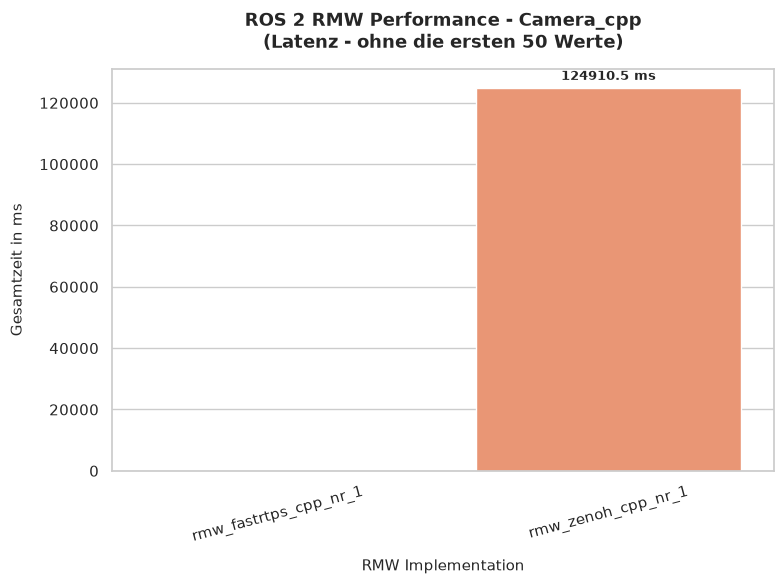

Das Diagramm für 'Camera_cpp' wurde erfolgreich als 'rmw_performance_camera_cpp.png' gespeichert!


/tmp/ipykernel_167952/929659666.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


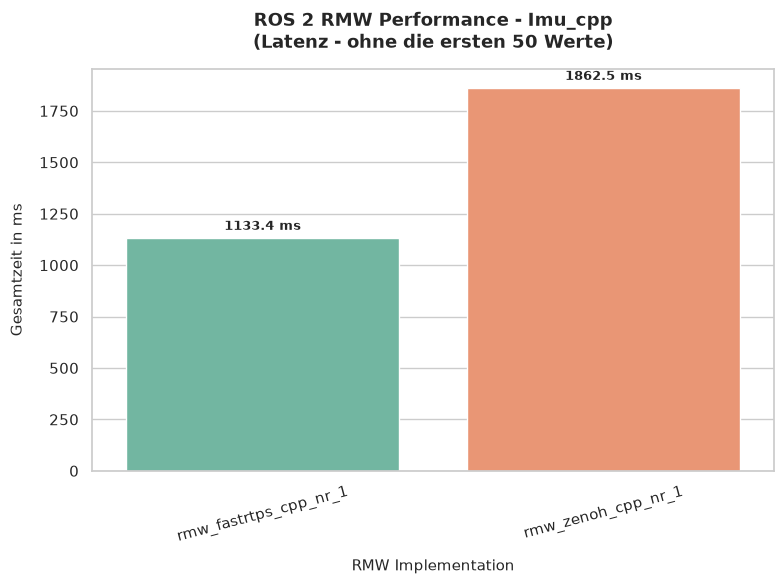

Das Diagramm für 'Imu_cpp' wurde erfolgreich als 'rmw_performance_imu_cpp.png' gespeichert!


/tmp/ipykernel_167952/929659666.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


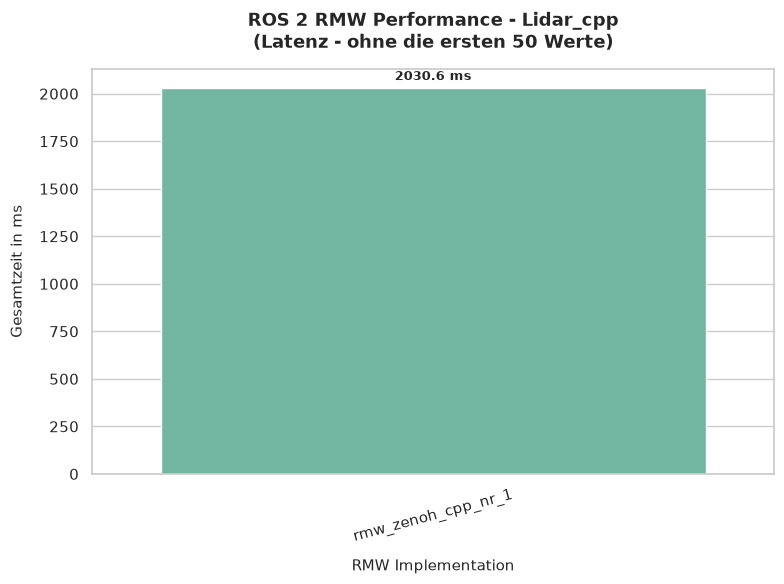

Das Diagramm für 'Lidar_cpp' wurde erfolgreich als 'rmw_performance_lidar_cpp.png' gespeichert!


In [2]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pfad zum Ordner mit den Textdateien definieren
folder_path = '../messurement'  # Dein angepasster Pfad

# 2. Datenstrukturen vorbereiten
txt_files = glob.glob(os.path.join(folder_path, '*.txt'))
parsed_data = []

# 3. Dateien automatisiert auslesen und parsen
for file_path in txt_files:
    file_name = os.path.basename(file_path)
    
    # Regulärer Ausdruck für Sensor und RMW-Namen
    match = re.match(r"([a-zA-Z0-9_]+)_results_(rmw_[a-zA-Z0-9_]+)\.txt", file_name)
    
    if not match:
        continue  
        
    sensor_type = match.group(1).capitalize()  # "Camera" oder "Lidar"

    rmw_name = match.group(2)                  # z.B. "rmw_fastrtps_cpp"
    
    total_nanoseconds = 0
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            entry_count = 0  # Zähler für die Einträge in der aktuellen Datei
            for line in file:
                cleaned_line = line.strip()
                if not cleaned_line:
                    continue
                
                # Zähler für gültige Einträge erhöhen
                entry_count += 1
                
                # Die ersten 50 Einträge verwerfen
                if entry_count <= 50:
                    continue
                
                number_part = cleaned_line.split()[0]
                total_nanoseconds += int(number_part)
                
        # In Millisekunden umrechnen
        total_milliseconds = total_nanoseconds / 1_000_000
        
        parsed_data.append({
            "Sensor": sensor_type,
            "RMW Implementation": rmw_name,
            "Gesamtzeit (ms)": total_milliseconds
        })
    except Exception as e:
        print(f"Fehler beim Parsen von {file_name}: {e}")

# 4. DataFrame erstellen und separate Plots generieren
df = pd.DataFrame(parsed_data)

if df.empty:
    print("Keine passenden Daten zum Plotten gefunden. Überprüfe die Dateinamen!")
else:
    # Sortieren für eine saubere Reihenfolge der Balken
    df = df.sort_values(by="Gesamtzeit (ms)")

    # Plot-Design festlegen
    sns.set_theme(style="whitegrid")
    
    # Schleife über jede einzigartige Kategorie (Sensortyp)
    for sensor_type in df["Sensor"].unique():
        # Daten für die aktuelle Kategorie filtern
        df_filtered = df[df["Sensor"] == sensor_type]
        
        # Erstelle eine neue Figure für jede Kategorie
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # Einzelnes Balkendiagramm (x-Achse ist jetzt die RMW-Implementierung)
        barplot = sns.barplot(
            x="RMW Implementation", 
            y="Gesamtzeit (ms)", 
            data=df_filtered, 
            palette="Set2",
            ax=ax
        )
        
        # Titel und Achsen beschriften (dynamisch angepasst an die Kategorie)
        plt.title(f"ROS 2 RMW Performance - {sensor_type}\n(Latenz - ohne die ersten 50 Werte)", fontsize=13, fontweight='bold', pad=15)
        plt.xlabel("RMW Implementation", fontsize=11, labelpad=10)
        plt.ylabel("Gesamtzeit in ms", fontsize=11, labelpad=10)
        
        # Falls die Namen der RMW-Implementierungen lang sind, leicht rotieren
        plt.xticks(rotation=15)
        
        # Exakte Werte über die Balken schreiben
        for p in barplot.patches:
            if p.get_height() > 0:
                barplot.annotate(
                    f"{p.get_height():.1f} ms",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=9,
                    fontweight='semibold'
                )
                
        plt.tight_layout()
        
        # Dynamischen Dateinamen basierend auf der Kategorie erstellen
        file_name = f"rmw_performance_{sensor_type.lower()}.png"
        plt.savefig(file_name, dpi=300)
        plt.show()  
        
        print(f"Das Diagramm für '{sensor_type}' wurde erfolgreich als '{file_name}' gespeichert!")

/tmp/ipykernel_120588/2549132933.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
findfont: Failed to find font weight semibold, now using 700.


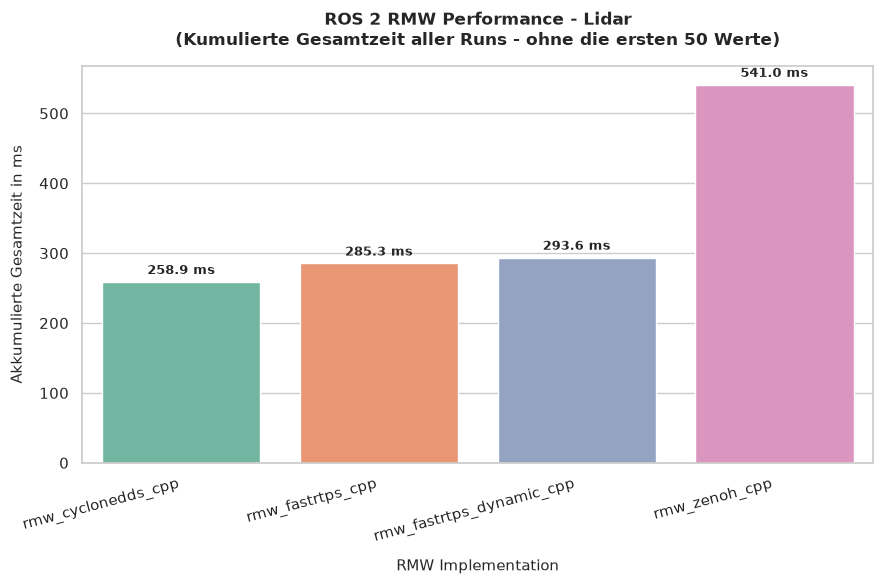

Das Diagramm für 'Lidar' (addierte Runs) wurde erfolgreich als 'rmw_performance_total_lidar.png' gespeichert!


/tmp/ipykernel_120588/2549132933.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


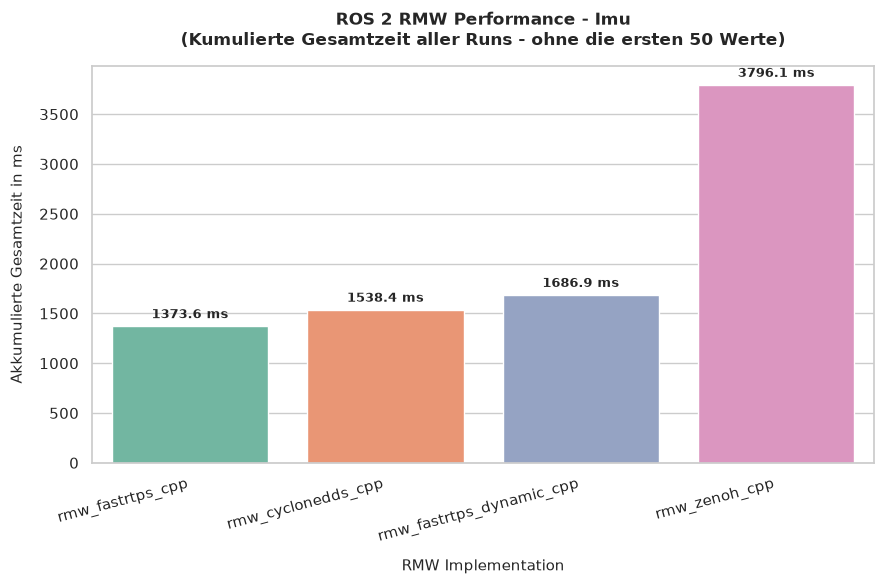

Das Diagramm für 'Imu' (addierte Runs) wurde erfolgreich als 'rmw_performance_total_imu.png' gespeichert!


In [1]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pfad zum Ordner mit den Textdateien definieren
folder_path = '../messurement'  # Dein angepasster Pfad

# 2. Datenstrukturen vorbereiten
txt_files = glob.glob(os.path.join(folder_path, '*.txt'))
parsed_raw_data = []

# 3. Dateien automatisiert auslesen und parsen
for file_path in txt_files:
    file_name = os.path.basename(file_path)
    
    # Neuer regulärer Ausdruck, der auch das "nr_X" am Ende matcht
    # Erkennt z.B.: imu_cpp_results_rmw_cyclonedds_cppnr_1.txt
    match = re.match(r"([a-zA-Z0-9]+)_cpp_results_(rmw_[a-zA-Z0-9_]+)_nr_\d+\.txt", file_name)
    
    if not match:
        continue  
        
    sensor_type = match.group(1).capitalize()  # "Imu" oder "Lidar"
    rmw_name = match.group(2)                  # z.B. "rmw_cyclonedds_cpp"
    
    total_nanoseconds = 0
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            entry_count = 0  # Zähler für die Einträge in der aktuellen Datei
            for line in file:
                cleaned_line = line.strip()
                if not cleaned_line:
                    continue
                
                # Zähler für gültige Einträge erhöhen
                entry_count += 1
                
                # Die ersten 10 Einträge verwerfen
                if entry_count <= 10:
                    continue
                
                number_part = cleaned_line.split()[0]
                total_nanoseconds += int(number_part)
                
        # In Millisekunden umrechnen
        total_milliseconds = total_nanoseconds / 1_000_000
        
        # Hier speichern wir erst mal jeden einzelnen Run ab
        parsed_raw_data.append({
            "Sensor": sensor_type,
            "RMW Implementation": rmw_name,
            "Gesamtzeit (ms)": total_milliseconds
        })
    except Exception as e:
        print(f"Fehler beim Parsen von {file_name}: {e}")

# 4. DataFrame erstellen und Daten aggregieren
df_raw = pd.DataFrame(parsed_raw_data)

if df_raw.empty:
    print("Keine passenden Daten zum Plotten gefunden. Überprüfe die Dateinamen und Struktur!")
else:
    # HIER PASSIERT DIE MAGIE: Alle Runs der gleichen RMW + Sensor werden aufaddiert
    df = df_raw.groupby(["Sensor", "RMW Implementation"], as_index=False)["Gesamtzeit (ms)"].sum()
    
    # Sortieren für eine saubere Reihenfolge der Balken
    df = df.sort_values(by="Gesamtzeit (ms)")

    # Plot-Design festlegen
    sns.set_theme(style="whitegrid")
    
    # Schleife über jede einzigartige Kategorie (Sensortyp)
    for sensor_type in df["Sensor"].unique():
        # Daten für die aktuelle Kategorie filtern
        df_filtered = df[df["Sensor"] == sensor_type]
        
        # Erstelle eine neue Figure für jede Kategorie
        fig, ax = plt.subplots(figsize=(9, 6))
        
        # Einzelnes Balkendiagramm
        barplot = sns.barplot(
            x="RMW Implementation", 
            y="Gesamtzeit (ms)", 
            data=df_filtered, 
            palette="Set2",
            ax=ax
        )
        
        # Titel und Achsen beschriften (Summiert-Hinweis hinzugefügt)
        plt.title(f"ROS 2 RMW Performance - {sensor_type}\n(Kumulierte Gesamtzeit aller Runs - ohne die ersten 50 Werte)", fontsize=12, fontweight='bold', pad=15)
        plt.xlabel("RMW Implementation", fontsize=11, labelpad=10)
        plt.ylabel("Akkumulierte Gesamtzeit in ms", fontsize=11, labelpad=10)
        
        # RMW-Namen leicht rotieren, falls sie lang sind
        plt.xticks(rotation=15, ha='right')
        
        # Exakte Werte über die Balken schreiben
        for p in barplot.patches:
            if p.get_height() > 0:
                barplot.annotate(
                    f"{p.get_height():.1f} ms",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=9,
                    fontweight='semibold'
                )
                
        plt.tight_layout()
        
        # Dynamischen Dateinamen basierend auf der Kategorie erstellen
        file_name = f"rmw_performance_total_{sensor_type.lower()}.png"
        plt.savefig(file_name, dpi=300)
        plt.show()  
        
        print(f"Das Diagramm für '{sensor_type}' (addierte Runs) wurde erfolgreich als '{file_name}' gespeichert!")